In [2]:
from src import clustering, graph_utils, plotting
import spatialdata as sd
import os 
# from napari_spatialdata import Interactive

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
dirs = os.listdir("C://Users//laure//Desktop//github//sys_gen//zarr")

In [4]:
dirs

['human_bone_marrow_acute_lymphoid_leukemia',
 'human_brain_preview',
 'human_non_diseased_lung',
 'mouse_bone_formic_acid_decalcification',
 'mouse_brain_replicate_1',
 'mouse_colon']

In [3]:
sdata = sd.read_zarr("zarr/mouse_brain_replicate_1.zarr")
adata = sdata.tables["table"]

/home/ktang/anaconda3/envs/single_cell_p311/lib/python3.11/site-packages/zarr/core/group.py:3535: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(
/home/ktang/anaconda3/envs/single_cell_p311/lib/python3.11/site-packages/zarr/core/group.py:3535: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


In [4]:
graph_utils.get_distances(adata, k=1, log=True)

In [5]:
results = clustering.fit_gmm(adata, distance_key="1_nn_distance", k_range=range(1,10))

Fitted GMM with k=1
Fitted GMM with k=2
Fitted GMM with k=3
Fitted GMM with k=4
Fitted GMM with k=5
Fitted GMM with k=6
Fitted GMM with k=7
Fitted GMM with k=8
Fitted GMM with k=9


Let's visualize the scores by number of components to see which is the optimal k to choose:

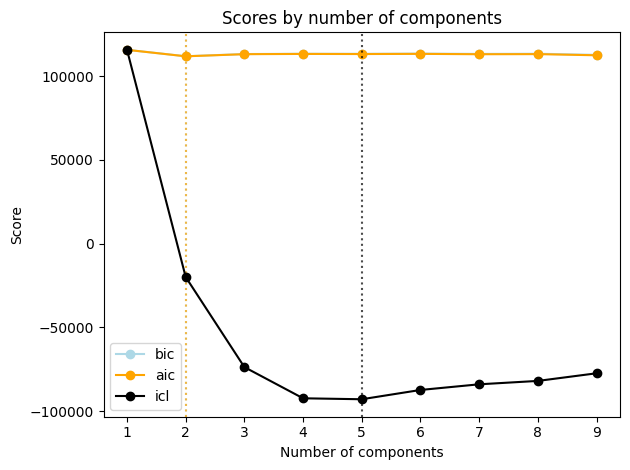

In [6]:
plotting.plot_scores(results)

BIC and AIC are almost identical which is why they overlap. Looking at ICL one can very well see a minimum. Let's pick the model with minimum ICL and continue with that.

In [7]:
best_model = clustering.choose_component(results, delta_bic_threshold=10.0)

Now we just assign the GMM labels to our cells, construct the neighbor graph and place seeds for watershed.

In [8]:
adata.obs["gmm_labels"] = best_model["labels"]
adata.obs["gmm_labels"] = adata.obs["gmm_labels"].astype("category") 

By providing the gmm labels as library id, we construct neighbor graphs for each gmm domain separately. In the end we have one adjacency block matrix, each block representing a domain.

In [17]:
graph_utils.get_neighbors(adata, type="knn")

In [18]:
graph_utils.prune_graph(adata, "gmm_labels")

/home/ktang/Adaptive-Niche/src/graph_utils.py:46: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  row_label = adata.obs[gmm_key][i]
/home/ktang/Adaptive-Niche/src/graph_utils.py:50: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  keep = adata.obs[gmm_key][neigh] == row_label


Now we run a variety of clustering algorithms to see how they differ. Note that kmeans is applied on the distance values and dbscan is applied on the coordinates, while watershed and leiden make use of the adjacency matrix.

In [19]:
for flavor in ["watershed"]:
    clustering.watershed_by_descent(adata, distances_key="1_nn_distance", spatial_connectivity_key="pruned_spatial_connectivities")

To finish off, we assign unique colors to our niche labels such that we can visualize it using napari-spatialdata.

In [20]:
plotting.assign_colors(sdata, "watershed_by_descent")

In [21]:
adata.obs["watershed_by_descent"].nunique()

56507

In [ ]:
Interactive(sdata)

2026-02-03 00:20:58.512 | WARNING  | napari_spatialdata._viewer:__init__:57 - Due to Shift-L being used as shortcut in napari, it is being deprecated and might not link a new layer to an existing SpatialData object in the viewer. Please use ⌘-L on MacOS or else Ctrl-L.


2026-02-03 00:21:02.808 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.
2026-02-03 00:21:03.056 | DEBUG    | napari_spatialdata._view:_on_layer_update:569 - Updating layer.


Plotting niche statistics

/home/ktang/Adaptive-Niche/src/plotting.py:294: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(category_col, as_index=False)[raw_cols]


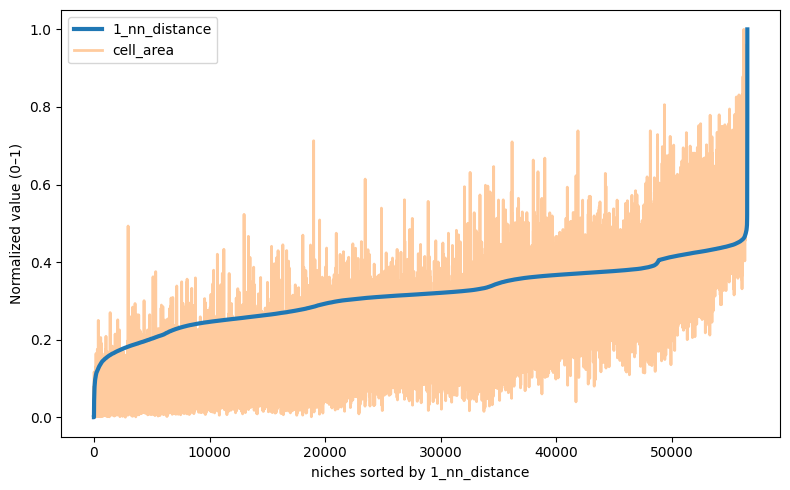

In [22]:
plotting.plot_niche_stats(sdata.tables["table"], col_keys=["1_nn_distance", "cell_area"], category_key="watershed_by_descent", sort_by="1_nn_distance")

/home/ktang/Adaptive-Niche/src/plotting.py:294: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(category_col, as_index=False)[raw_cols]
/home/ktang/Adaptive-Niche/src/plotting.py:302: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(category_col)


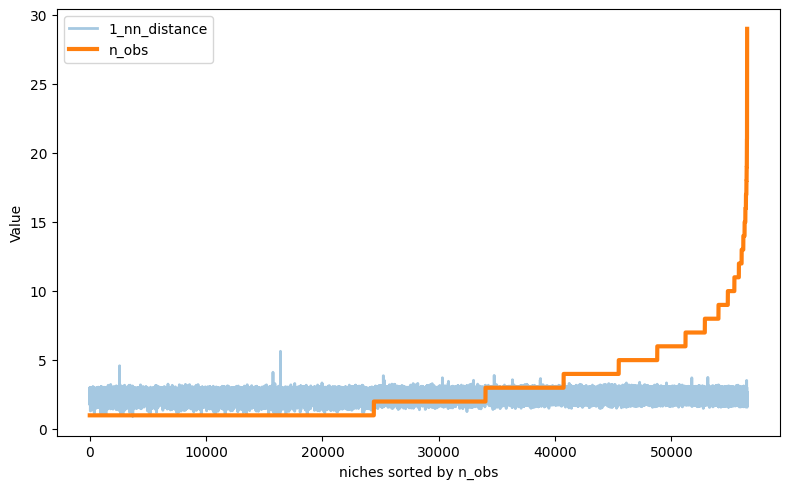

In [23]:
plotting.plot_niche_stats(sdata.tables["table"], col_keys=["1_nn_distance","n_obs"], category_key="watershed_by_descent", sort_by="n_obs", normalize=False)

In [25]:
adata = sdata.tables["table"][sdata.tables["table"].obs["watershed_by_descent"] == 0]

In [26]:
import squidpy as sq
sq.pl.spatial_scatter(adata, color=["1_nn_distance","gmm_labels"], shape=None)

/home/ktang/anaconda3/envs/single_cell_p311/lib/python3.11/site-packages/squidpy/pl/_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]


ZeroDivisionError: division by zero

In [27]:
adata

AnnData object with n_obs × n_vars = 0 × 248
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', '1_nn_distance', 'gmm_labels', 'watershed_by_descent'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs', 'spatial_neighbors', 'watershed_by_descent_colors', 'gmm_labels_colors'
    obsm: 'spatial'
    obsp: 'spatial_connectivities', 'spatial_distances', 'pruned_spatial_connectivities', 'pruned_spatial_distances'

In [25]:
sdata.tables["table"].obs.groupby("watershed_niches").size().reset_index(name="n_obs")

C:\Users\laure\AppData\Local\Temp\ipykernel_27852\3005171559.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sdata.tables["table"].obs.groupby("watershed_niches").size().reset_index(name="n_obs")


,watershed_niches,n_obs
0,0,52842
1,1,1
2,2,3
3,3,2
4,4,2
...,...,...
20644,20644,2
20645,20645,3
20646,20646,8
20647,20647,11
